# Travis County Week 1 EDA

> Research lead: Khadeja

This notebook is the week 1 exploration workspace for the Travis County criminal justice dataset. The immediate goals are to:

- inventory the available files
- preview the core CSV schemas
- identify likely linkage keys across person, booking, case, and pretrial records
- flag proxy-variable risks and open data questions for Friday discussion

In [1]:
import csv
from pathlib import Path

import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
CORE_FILES = [
    "Booking2010_2012v3.csv",
    "Booking2013_2016v3.csv",
    "CaseData_v2.csv",
    "PreTrial Charge-Interview.csv",
]

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory exists: {RAW_DATA_DIR.exists()}")
print(f"Pandas version: {pd.__version__}")

Project root: C:\Users\khade\Documents\GitHub\Bias-and-Fairness-in-AI-governance
Raw data directory exists: True
Pandas version: 3.0.3


In [3]:
def build_inventory(data_dir: Path) -> list[dict[str, object]]:
    records = []
    for path in sorted(data_dir.iterdir()):
        if path.is_file():
            records.append(
                {
                    "file": path.name,
                    "suffix": path.suffix.lower(),
                    "size_mb": round(path.stat().st_size / (1024 * 1024), 2),
                }
            )
    return records

inventory = build_inventory(RAW_DATA_DIR)
inventory_df = pd.DataFrame(inventory).sort_values(["suffix", "file"]).reset_index(drop=True)

print(f"Raw file count: {len(inventory_df)}")
display(inventory_df)

Raw file count: 18


,file,suffix,size_mb
0,Booking2010_2012v3.csv,.csv,62.78
1,Booking2013_2016v3.csv,.csv,63.32
2,CaseData_v2.csv,.csv,110.94
3,PreTrial Charge-Interview.csv,.csv,83.48
4,chargecode_description.dta,.dta,0.43
5,171017_CCHCodes_Violent marked by Slayton.xlsx,.xlsx,0.11
6,CaseIDtoBookingChargeIDUPDATED.xlsx,.xlsx,8.83
7,Events.xlsx,.xlsx,4.12
8,Mental Health Flag Events.xlsx,.xlsx,3.69
9,PersonData.xlsx,.xlsx,5.21


In [4]:
def read_csv_header(path: Path) -> list[str]:
    with path.open("r", newline="", encoding="utf-8-sig") as handle:
        reader = csv.reader(handle)
        return next(reader)

def preview_rows(path: Path, limit: int = 3) -> list[dict[str, str]]:
    rows = []
    with path.open("r", newline="", encoding="utf-8-sig") as handle:
        reader = csv.DictReader(handle)
        for index, row in enumerate(reader):
            if index >= limit:
                break
            rows.append(row)
    return rows

schema_preview = []
for file_name in CORE_FILES:
    path = RAW_DATA_DIR / file_name
    header = read_csv_header(path)
    schema_preview.append(
        {
            "file": file_name,
            "column_count": len(header),
            "first_columns": ", ".join(header[:12]),
        }
    )

schema_preview_df = pd.DataFrame(schema_preview)
display(schema_preview_df)

,file,column_count,first_columns
0,Booking2010_2012v3.csv,43,"bookingID, BookingNumber, mni, PersonID, jailID, CustodyStatusID, CustodyTypeID, bookingdate, bookingtime, ReleaseDa..."
1,Booking2013_2016v3.csv,43,"bookingID, BookingNumber, mni, PersonID, jailID, CustodyStatusID, CustodyTypeID, bookingdate, bookingtime, ReleaseDa..."
2,CaseData_v2.csv,81,"CaseID, DivisionID, CourtTypeID, CaseTypeID, CaseStatusID, StatusDate, CaseStateID, SealedFlag, RestrictedFlag, Case..."
3,PreTrial Charge-Interview.csv,37,"PA_MAST_NO, PK_BKG_NO, BJ_BK_DATE, PK_CHG_DT, INT_OFF, OFF_REC, PK_BND_REC, PK_BND_GRT, PK_GRNT_DT, PK_ATY_REC, PK_A..."


In [5]:
sample_file = RAW_DATA_DIR / "CaseData_v2.csv"
sample_rows = preview_rows(sample_file, limit=5)
sample_df = pd.DataFrame(sample_rows)

display(sample_df)

,CaseID,DivisionID,CourtTypeID,CaseTypeID,CaseStatusID,StatusDate,CaseStateID,SealedFlag,RestrictedFlag,CaseInitiationDate,DateCaseEntered,ReindictRefile,CaseStateIssue,LatestCasePhaseID,LatestAgeofPendingComplaint,CriminalDefendantID,PartyID,PersonID,MNI,OriginalBookingNumber,BookingDate,IndictFilingDate,CalendarDaysBookingtoIndictFiling,JailCaseTypeID,HighestLevelChargeCount,HighestLevelDispositionCount,CaseChargeID,CountNumber,ChargeCode,CsMgmtChargeID,CurrentChargeStateID,ChargeReducedEnhanced,OriginalDispositionPleaID,OriginalDispositionPleaDate,OriginalDispositionTrialTypeID,OriginalDispositionVerdictID,OriginalDispositionVerdictDate,OriginalDispositionMethodID,OriginalDispositionID,OriginalDispositionDate,OriginalDispositionEvent,OriginalSentenceID,LatestDispositionMethodID,LatestDispositionID,LatestDispositionDate,LatestSentenceID,EarliestKnownChargeID,OffenseDate,CriminalDefendantHistoryID,ActivationDate,ActivationEventID,ActivationTypeID,AssociatedBookingNumber,AssociatedBookingDate,InactivityDays,CalendarDaysFilingtoCurrent,AgeofCase,DispositionID,DispositionDate,DispositionEventID,DispositionTypeID,CalendarDaysFilingtoDisposition,TimetoDisposition,casephaseID,CasePhaseCode,UnabletoCalcAgeInactivity,DispositionMethodID,PartyAttorneyID,PartyIDRepresenting,attorneyID,AttorneySBN,AttorneyCounselTypeID,AttorneyCaseStatusID,AttorneyStatusDateTime,CurrentAttorneyFlag,AttorneyStartDate,AttorneyEndDate,CurrentLeadAttorneyFlag,AssignedCourtID,OriginalDispositionCourtID,LatestDispositonCourtID
0,1381881,2,1,203,142,11/18/2010,3,0,0,8/30/2010,8/30/2010,NULL,NULL,NULL,NULL,911820,3383654,250381,847199,1041441,8/26/2010,9/3/2010,9,4,1,1,18919,1,41990018,5475,2,NULL,2,11/18/2010,2,NULL,NULL,2,171,11/18/2010,9038,20,NULL,NULL,NULL,NULL,5475,8/26/2010,1855380,9/3/2010,5559,31,1041441,8/26/2010,70,NULL,NULL,171,11/18/2010,4842,1,77,7,1,ORIGINAL,0,2,731706,3383654,973,784356,17,8,11/16/2010,Y,NULL,NULL,Y,J65,J65,NULL
1,1398852,2,1,195,142,10/2/2013,3,0,0,1/5/2011,1/5/2011,NULL,NULL,NULL,NULL,445098,3417539,305159,1125250,1062013,12/28/2010,2/2/2011,37,5,1,1,18920,1,35620008,1716,2,NULL,2,9/14/2011,2,NULL,NULL,2,171,9/14/2011,9038,20,NULL,NULL,NULL,NULL,1716,12/3/2010,1485448,2/2/2011,5559,31,1062013,12/28/2010,3,NULL,NULL,171,9/14/2011,4842,1,225,222,1,ORIGINAL,0,2,513670,3417539,53004,13142050,30,8,2/8/2011,Y,NULL,NULL,Y,J65,J65,NULL
2,1437533,2,1,203,142,10/2/2012,3,0,0,11/21/2011,11/21/2011,NULL,NULL,NULL,NULL,171165,3497488,420243,1811100,1153225,11/19/2011,12/19/2011,31,5,1,1,18939,1,54040009,1513,2,NULL,2,10/2/2012,2,NULL,NULL,2,171,10/2/2012,9038,20,NULL,NULL,NULL,NULL,1513,11/19/2011,1499896,12/19/2011,5559,31,1153225,11/19/2011,NULL,NULL,NULL,171,10/2/2012,4842,1,289,289,1,ORIGINAL,0,2,566513,3497488,98561,24038749,30,8,12/16/2011,Y,NULL,NULL,Y,J33,J33,NULL
3,1513292,2,1,203,142,10/2/2015,3,0,0,7/11/2013,7/11/2013,NULL,NULL,NULL,NULL,921091,3644210,441243,1908301,1329693,7/10/2013,8/6/2013,28,5,1,1,18943,1,54040009,1513,2,NULL,1,12/2/2013,2,NULL,NULL,2,101,12/2/2013,9002,20,4,102,10/2/2015,20,1513,7/10/2013,1901930,8/6/2013,5559,31,1329693,7/10/2013,NULL,NULL,NULL,101,12/2/2013,4806,1,119,119,1,ORIGINAL,0,2,1210246,3644210,9000,792684,17,8,9/30/2015,Y,NULL,NULL,Y,J33,J33,J10
4,1506253,2,1,195,138,9/24/2013,3,0,0,5/24/2013,5/24/2013,NULL,NULL,NULL,NULL,486104,3633626,246217,796986,1321738,5/21/2013,6/14/2013,25,5,1,1,18956,1,54990067,4148,2,NULL,NULL,NULL,2,NULL,NULL,2,147,9/24/2013,9030,20,NULL,NULL,NULL,NULL,4148,4/30/2013,1904033,6/14/2013,5559,31,1321738,5/21/2013,NULL,NULL,NULL,147,9/24/2013,4834,4,103,103,1,ORIGINAL,0,2,754205,3633626,112459,24058588,24,8,6/19/2013,Y,NULL,NULL,Y,J33,J33,NULL


In [16]:
linkage_hypotheses = [
    {"entity": "person", "candidate_keys": "PersonID, mni/MNI", "source_files": "Booking, Case, likely PersonData"},
    {"entity": "booking", "candidate_keys": "bookingID, BookingNumber, AssociatedBookingNumber, PK_BKG_NO", "source_files": "Booking, Case, PreTrial"},
    {"entity": "charge", "candidate_keys": "BookingChargeID, CaseChargeID, ChargeCode", "source_files": "Booking, Case, charge lookup"},
    {"entity": "case", "candidate_keys": "CaseID", "source_files": "CaseData, bridge workbook"},
    {"entity": "pretrial interview", "candidate_keys": "PA_MAST_NO, PK_BKG_NO, PK_CHARGE", "source_files": "PreTrial Charge-Interview"},
]

linkage_df = pd.DataFrame(linkage_hypotheses)
display(linkage_df)

,entity,candidate_keys,source_files
0,person,"PersonID, mni/MNI","Booking, Case, likely PersonData"
1,booking,"bookingID, BookingNumber, AssociatedBookingNumber, PK_BKG_NO","Booking, Case, PreTrial"
2,charge,"BookingChargeID, CaseChargeID, ChargeCode","Booking, Case, charge lookup"
3,case,CaseID,"CaseData, bridge workbook"
4,pretrial interview,"PA_MAST_NO, PK_BKG_NO, PK_CHARGE",PreTrial Charge-Interview


## Priority Workbook Inspection

This section starts the week 1 inspection of the three highest-priority Excel workbooks:

- `PersonData.xlsx`
- `PreTrial to Booking Info.xlsx`
- `CaseIDtoBookingChargeIDUPDATED.xlsx`

The goal is to identify sheet structure, likely join keys, and the first columns worth documenting in the data inventory.

In [6]:
PRIORITY_WORKBOOKS = [
    "PersonData.xlsx",
    "PreTrial to Booking Info.xlsx",
    "CaseIDtoBookingChargeIDUPDATED.xlsx",
]

def inspect_workbook(file_name: str) -> list[dict[str, object]]:
    workbook_path = RAW_DATA_DIR / file_name
    excel_file = pd.ExcelFile(workbook_path)
    rows = []
    for sheet_name in excel_file.sheet_names:
        sheet_preview = pd.read_excel(workbook_path, sheet_name=sheet_name, nrows=0)
        rows.append(
            {
                "workbook": file_name,
                "sheet_name": sheet_name,
                "column_count": len(sheet_preview.columns),
                "first_columns": ", ".join(sheet_preview.columns.astype(str)[:10]),
            }
        )
    return rows

workbook_sheet_rows = []
for workbook_name in PRIORITY_WORKBOOKS:
    workbook_sheet_rows.extend(inspect_workbook(workbook_name))

workbook_sheet_df = pd.DataFrame(workbook_sheet_rows)
display(workbook_sheet_df)

,workbook,sheet_name,column_count,first_columns
0,PersonData.xlsx,PersonData,7,"PersonID, MNI, DateofBirth, GenderID, RaceID, EthnicityID, CitizenshipID"
1,PreTrial to Booking Info.xlsx,Booking,11,"PA_MAST_NO, BH_BKG_NO, BJ_BK_DATE, BH_WAR_NO, BH_C_CASE, BH_BAIL_AMT, BH_CHG_DATE, BH_JCHG_NO, BH_CRT_DATE, BH_CRT_TIME"
2,CaseIDtoBookingChargeIDUPDATED.xlsx,Sheet2,2,"BookingChargeID, CaseID"
3,CaseIDtoBookingChargeIDUPDATED.xlsx,Sheet3,0,


In [7]:
for workbook_name in PRIORITY_WORKBOOKS:
    workbook_path = RAW_DATA_DIR / workbook_name
    excel_file = pd.ExcelFile(workbook_path)
    first_sheet_name = excel_file.sheet_names[0]
    preview_df = pd.read_excel(workbook_path, sheet_name=first_sheet_name, nrows=5)

    print(f"Workbook: {workbook_name}")
    print(f"First sheet: {first_sheet_name}")
    display(preview_df.head())

Workbook: PersonData.xlsx
First sheet: PersonData


,PersonID,MNI,DateofBirth,GenderID,RaceID,EthnicityID,CitizenshipID
0,69724,1172445,1984-06-19,1,7,NaN,1
1,135247,782761,1974-09-15,1,7,1.0,1
2,135253,782777,1977-02-22,2,7,NaN,1
3,135265,782803,1977-08-16,1,7,1.0,2
4,135273,782741,1982-04-16,1,7,1.0,1


Workbook: PreTrial to Booking Info.xlsx
First sheet: Booking


,PA_MAST_NO,BH_BKG_NO,BJ_BK_DATE,BH_WAR_NO,BH_C_CASE,BH_BAIL_AMT,BH_CHG_DATE,BH_JCHG_NO,BH_CRT_DATE,BH_CRT_TIME,BH_CRT_EVT
0,PT10000002,1000003,2010-01-01,NaN,C1CR10200039,5000,2010-01-01,1,2010-01-01,816,ARR
1,PT10000003,1000003,2010-01-01,NaN,C1CR10200039,5000,2010-01-01,1,2010-01-01,816,ARR
2,PT10000005,1000008,2010-01-01,NaN,NaN,0,2010-01-01,2,NaT,0,NaN
3,PT10000005,1000008,2010-01-01,NaN,NaN,0,2010-01-01,1,NaT,0,NaN
4,PT10000005,1000008,2010-01-01,NaN,C1CR10200038,1000,2010-01-01,3,2010-01-01,816,ARR


Workbook: CaseIDtoBookingChargeIDUPDATED.xlsx
First sheet: Sheet2


,BookingChargeID,CaseID
0,1276847,408393
1,1265925,408402
2,1512394,408402
3,1544613,408402
4,1440905,408402


## Initial Inspection Findings

- `PersonData.xlsx` appears to contain direct demographic attributes at the person level, including `GenderID`, `RaceID`, `EthnicityID`, and `CitizenshipID`. This is the clearest current source for protected or sensitive attributes.
- `PreTrial to Booking Info.xlsx` looks like a bridge between pretrial records and booking or case records because it contains `PA_MAST_NO`, booking-number style fields, case-like fields, charge dates, and court event fields.
- `CaseIDtoBookingChargeIDUPDATED.xlsx` is a narrow mapping table that directly links `BookingChargeID` to `CaseID`, which should help connect booking charge records to case-level outcomes.
- These three workbooks materially strengthen the current linkage hypothesis across person, booking, charge, case, and pretrial entities.

## Written Data Relationship Map

The file set looks most naturally like a linked justice-process pipeline rather than one flat table.

- **Person anchor**: `PersonData.xlsx` is the clearest person-level table. `PersonID` and `MNI` appear in `PersonData.xlsx`, both booking CSVs, and `CaseData_v2.csv`, making it the strongest route for attaching demographics to bookings and cases. `PreTrial Defendants.xlsx` likely joins into that same person layer through `PB_MNI` and booking-level context.
- **Booking anchor**: the two booking CSVs appear to be the operational hub for jail intake and charge rows. `BookingNumber` is the strongest shared booking identifier because it is mirrored by `AssociatedBookingNumber` and `OriginalBookingNumber` in `CaseData_v2.csv`, by `PK_BKG_NO` in `PreTrial Charge-Interview.csv`, by `PA_BKG_NO` in `PreTrial Defendants.xlsx`, and by `BH_BKG_NO` in `PreTrial to Booking Info.xlsx`.
- **Case anchor**: `CaseData_v2.csv` is the main case-outcomes table. `CaseID` is the direct case key and is reused in `CaseIDtoBookingChargeIDUPDATED.xlsx`, the sentencing workbooks, and `revocationV2.xlsx`, so it is the best case-level connector for downstream outcomes.
- **Charge bridge**: `CaseIDtoBookingChargeIDUPDATED.xlsx` is the clearest explicit bridge between booking-side and case-side charge records because it links `BookingChargeID` to `CaseID`. `ChargeCode` also appears across booking, case, pretrial, and lookup files, but it is better treated as an offense classification key than as a unique row identifier.
- **Pretrial subgraph**: `PA_MAST_NO` appears to tie together `PreTrial Charge-Interview.csv`, `PreTrial Defendants.xlsx`, `PreTrial to Booking Info.xlsx`, and `PreTrial TCUD-ODAR Events.xlsx`. Within that subgraph, `PK_CNTY_NO`, `BH_C_CASE`, and `PL_BND_CASE` look like court-case-number style fields that may provide an additional route from pretrial activity back to court records.
- **Outcome extensions**: `SentencingDataPre2013.xlsx`, `SentencingDataPost2013.xlsx`, and `revocationV2.xlsx` appear to extend the case pathway after filing and disposition. `revocationV2.xlsx` also repeats booking-, person-, and charge-like fields, suggesting it can be joined both directly on `CaseID` and secondarily checked against `PersonID`, `MNI`, or booking-number fields.

A practical first-pass model is: `persons -> bookings -> booking charges -> cases -> sentencing/revocation`, with a parallel `pretrial` branch that joins into bookings through booking numbers and into cases through court-case-number style fields or the booking-to-case bridge.

In [8]:
from pathlib import Path

import pandas as pd
from IPython.display import display

analysis_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
analysis_data_dir = analysis_root / "data" / "raw"

def normalized_unique_csv(file_name: str, column: str, chunk_size: int = 100_000) -> set[str]:
    values: set[str] = set()
    for chunk in pd.read_csv(
        analysis_data_dir / file_name,
        usecols=[column],
        dtype={column: "string"},
        chunksize=chunk_size,
        low_memory=False,
    ):
        series = chunk[column].dropna().astype("string").str.strip()
        series = series[series != ""]
        values.update(series.tolist())
    return values

def normalized_unique_excel(file_name: str, sheet_name: str, column: str) -> set[str]:
    frame = pd.read_excel(
        analysis_data_dir / file_name,
        sheet_name=sheet_name,
        usecols=[column],
        dtype={column: "string"},
    )
    series = frame[column].dropna().astype("string").str.strip()
    series = series[series != ""]
    return set(series.tolist())

def summarize_overlap(group: str, left_label: str, left_values: set[str], right_label: str, right_values: set[str]) -> dict[str, object]:
    shared = left_values & right_values
    return {
        "relationship_group": group,
        "left": left_label,
        "right": right_label,
        "left_unique": len(left_values),
        "right_unique": len(right_values),
        "shared_unique": len(shared),
        "left_overlap_pct": round(len(shared) / len(left_values) * 100, 2) if left_values else 0.0,
        "right_overlap_pct": round(len(shared) / len(right_values) * 100, 2) if right_values else 0.0,
    }

booking_person = normalized_unique_csv("Booking2010_2012v3.csv", "PersonID") | normalized_unique_csv("Booking2013_2016v3.csv", "PersonID")
booking_mni = normalized_unique_csv("Booking2010_2012v3.csv", "mni") | normalized_unique_csv("Booking2013_2016v3.csv", "mni")
booking_number = normalized_unique_csv("Booking2010_2012v3.csv", "BookingNumber") | normalized_unique_csv("Booking2013_2016v3.csv", "BookingNumber")
booking_charge_id = normalized_unique_csv("Booking2010_2012v3.csv", "BookingChargeID") | normalized_unique_csv("Booking2013_2016v3.csv", "BookingChargeID")
booking_charge_code = normalized_unique_csv("Booking2010_2012v3.csv", "ChargeCode") | normalized_unique_csv("Booking2013_2016v3.csv", "ChargeCode")

case_person = normalized_unique_csv("CaseData_v2.csv", "PersonID")
case_mni = normalized_unique_csv("CaseData_v2.csv", "MNI")
case_assoc_booking = normalized_unique_csv("CaseData_v2.csv", "AssociatedBookingNumber")
case_orig_booking = normalized_unique_csv("CaseData_v2.csv", "OriginalBookingNumber")
case_id = normalized_unique_csv("CaseData_v2.csv", "CaseID")
case_charge_id = normalized_unique_csv("CaseData_v2.csv", "CaseChargeID")
case_charge_code = normalized_unique_csv("CaseData_v2.csv", "ChargeCode")

person_person = normalized_unique_excel("PersonData.xlsx", "PersonData", "PersonID")
person_mni = normalized_unique_excel("PersonData.xlsx", "PersonData", "MNI")

pretrial_pa = normalized_unique_csv("PreTrial Charge-Interview.csv", "PA_MAST_NO")
pretrial_booking = normalized_unique_csv("PreTrial Charge-Interview.csv", "PK_BKG_NO")
pretrial_case_number = normalized_unique_csv("PreTrial Charge-Interview.csv", "PK_CNTY_NO")
pretrial_charge_code = normalized_unique_csv("PreTrial Charge-Interview.csv", "PK_CHARGE")

pretrial_def_pa = normalized_unique_excel("PreTrial Defendants.xlsx", "Sheet1", "PA_MAST_NO")
pretrial_def_booking = normalized_unique_excel("PreTrial Defendants.xlsx", "Sheet1", "PA_BKG_NO")
pretrial_def_mni = normalized_unique_excel("PreTrial Defendants.xlsx", "Sheet1", "PB_MNI")

pretrial_bridge_pa = normalized_unique_excel("PreTrial to Booking Info.xlsx", "Booking", "PA_MAST_NO")
pretrial_bridge_booking = normalized_unique_excel("PreTrial to Booking Info.xlsx", "Booking", "BH_BKG_NO")
pretrial_bridge_case_number = normalized_unique_excel("PreTrial to Booking Info.xlsx", "Booking", "BH_C_CASE")

tcud_pa = normalized_unique_excel("PreTrial TCUD-ODAR Events.xlsx", "Sheet1", "PA_MAST_NO")
bridge_case_id = normalized_unique_excel("CaseIDtoBookingChargeIDUPDATED.xlsx", "Sheet2", "CaseID")
bridge_booking_charge_id = normalized_unique_excel("CaseIDtoBookingChargeIDUPDATED.xlsx", "Sheet2", "BookingChargeID")
sentencing_case_id = normalized_unique_excel("SentencingDataPre2013.xlsx", "SentencingDataPre2013", "CaseID") | normalized_unique_excel("SentencingDataPost2013.xlsx", "SentencingDataPost2013", "CaseID")
revocation_case_id = normalized_unique_excel("revocationV2.xlsx", "revocation", "CaseID")
revocation_case_charge_id = normalized_unique_excel("revocationV2.xlsx", "revocation", "CaseChargeID")

relationship_rows = [
    summarize_overlap("person", "booking.PersonID", booking_person, "person.PersonID", person_person),
    summarize_overlap("person", "case.PersonID", case_person, "person.PersonID", person_person),
    summarize_overlap("person", "booking.mni", booking_mni, "person.MNI", person_mni),
    summarize_overlap("person", "case.MNI", case_mni, "person.MNI", person_mni),
    summarize_overlap("person", "pretrial_defendants.PB_MNI", pretrial_def_mni, "person.MNI", person_mni),
    summarize_overlap("booking", "case.AssociatedBookingNumber", case_assoc_booking, "booking.BookingNumber", booking_number),
    summarize_overlap("booking", "case.OriginalBookingNumber", case_orig_booking, "booking.BookingNumber", booking_number),
    summarize_overlap("booking", "pretrial_charge.PK_BKG_NO", pretrial_booking, "booking.BookingNumber", booking_number),
    summarize_overlap("booking", "pretrial_defendants.PA_BKG_NO", pretrial_def_booking, "booking.BookingNumber", booking_number),
    summarize_overlap("booking", "pretrial_bridge.BH_BKG_NO", pretrial_bridge_booking, "booking.BookingNumber", booking_number),
    summarize_overlap("case", "case_bridge.CaseID", bridge_case_id, "case.CaseID", case_id),
    summarize_overlap("case", "sentencing.CaseID", sentencing_case_id, "case.CaseID", case_id),
    summarize_overlap("case", "revocation.CaseID", revocation_case_id, "case.CaseID", case_id),
    summarize_overlap("charge", "case_bridge.BookingChargeID", bridge_booking_charge_id, "booking.BookingChargeID", booking_charge_id),
    summarize_overlap("charge", "revocation.CaseChargeID", revocation_case_charge_id, "case.CaseChargeID", case_charge_id),
    summarize_overlap("charge", "booking.ChargeCode", booking_charge_code, "case.ChargeCode", case_charge_code),
    summarize_overlap("charge", "pretrial_charge.PK_CHARGE", pretrial_charge_code, "booking.ChargeCode", booking_charge_code),
    summarize_overlap("pretrial", "pretrial_charge.PA_MAST_NO", pretrial_pa, "pretrial_defendants.PA_MAST_NO", pretrial_def_pa),
    summarize_overlap("pretrial", "pretrial_charge.PA_MAST_NO", pretrial_pa, "pretrial_bridge.PA_MAST_NO", pretrial_bridge_pa),
    summarize_overlap("pretrial", "pretrial_charge.PA_MAST_NO", pretrial_pa, "pretrial_tcud.PA_MAST_NO", tcud_pa),
    summarize_overlap("pretrial", "pretrial_charge.PK_CNTY_NO", pretrial_case_number, "pretrial_bridge.BH_C_CASE", pretrial_bridge_case_number),
]

relationship_df = pd.DataFrame(relationship_rows).sort_values(["relationship_group", "shared_unique"], ascending=[True, False]).reset_index(drop=True)
display(relationship_df)

cardinality_df = pd.DataFrame(
    [
        {"entity": "booking", "key": "BookingNumber", "mean_rows_per_key": round(float(pd.concat([
            pd.read_csv(analysis_data_dir / "Booking2010_2012v3.csv", usecols=["BookingNumber"], dtype="string", low_memory=False),
            pd.read_csv(analysis_data_dir / "Booking2013_2016v3.csv", usecols=["BookingNumber"], dtype="string", low_memory=False),
        ], ignore_index=True).groupby("BookingNumber").size().mean()), 2)},
        {"entity": "case", "key": "CaseID", "mean_rows_per_key": round(float(pd.read_csv(
            analysis_data_dir / "CaseData_v2.csv",
            usecols=["CaseID"],
            dtype="string",
            low_memory=False,
        ).groupby("CaseID").size().mean()), 2)},
        {"entity": "pretrial", "key": "PA_MAST_NO", "mean_rows_per_key": round(float(pd.read_csv(
            analysis_data_dir / "PreTrial Charge-Interview.csv",
            usecols=["PA_MAST_NO"],
            dtype="string",
            low_memory=False,
        ).groupby("PA_MAST_NO").size().mean()), 2)},
        {"entity": "case_bridge", "key": "CaseID", "mean_rows_per_key": round(float(pd.read_excel(
            analysis_data_dir / "CaseIDtoBookingChargeIDUPDATED.xlsx",
            sheet_name="Sheet2",
            usecols=["CaseID"],
            dtype="string",
        ).groupby("CaseID").size().mean()), 2)},
    ]
 )
display(cardinality_df)

,relationship_group,left,right,left_unique,right_unique,shared_unique,left_overlap_pct,right_overlap_pct
0,booking,pretrial_bridge.BH_BKG_NO,booking.BookingNumber,233655,348800,233655,100.00,66.99
1,booking,pretrial_charge.PK_BKG_NO,booking.BookingNumber,233507,348800,233506,100.00,66.95
2,booking,pretrial_defendants.PA_BKG_NO,booking.BookingNumber,233506,348800,233505,100.00,66.95
3,booking,case.OriginalBookingNumber,booking.BookingNumber,191506,348800,189849,99.13,54.43
4,booking,case.AssociatedBookingNumber,booking.BookingNumber,173531,348800,173281,99.86,49.68
5,case,case_bridge.CaseID,case.CaseID,275699,259568,245484,89.04,94.57
6,case,sentencing.CaseID,case.CaseID,123674,259568,123663,99.99,47.64
7,case,revocation.CaseID,case.CaseID,13513,259568,11092,82.08,4.27
8,charge,case_bridge.BookingChargeID,booking.BookingChargeID,579075,578926,578590,99.92,99.94
9,charge,revocation.CaseChargeID,case.CaseChargeID,14844,269736,12006,80.88,4.45


,entity,key,mean_rows_per_key
0,booking,BookingNumber,1.66
1,case,CaseID,1.05
2,pretrial,PA_MAST_NO,1.70
3,case_bridge,CaseID,1.26


## Measured Relationship Evidence

The overlap table above supports the following join paths.

- **Pretrial to booking is very strong**: `BH_BKG_NO`, `PK_BKG_NO`, and `PA_BKG_NO` each overlap almost perfectly with booking `BookingNumber`. That makes booking number the most reliable bridge from the pretrial files into the booking extracts.
- **Pretrial files form a coherent subgraph**: `PA_MAST_NO` overlaps almost perfectly across `PreTrial Charge-Interview.csv`, `PreTrial Defendants.xlsx`, and `PreTrial to Booking Info.xlsx`. `PA_MAST_NO` also links a large subset of records into `PreTrial TCUD-ODAR Events.xlsx`.
- **Case to booking is strong but not complete**: both `OriginalBookingNumber` and `AssociatedBookingNumber` in `CaseData_v2.csv` match most booking numbers, which supports a booking-mediated path from cases back to jail intake records.
- **Case-charge bridging is especially strong**: `CaseIDtoBookingChargeIDUPDATED.xlsx` nearly fully overlaps with booking `BookingChargeID`, making it the clearest bridge between booking charge rows and case records.
- **Person linkage is strongest through `PersonData.xlsx`**: almost all `PersonID` and `MNI` values in `PersonData.xlsx` are represented in case records, and most are also represented in booking and pretrial-defendant records. This confirms `PersonData.xlsx` as the best demographic anchor.
- **Downstream outcomes connect primarily through `CaseID`**: sentencing case IDs almost fully overlap the case table, while revocation overlaps a smaller case subset. That suggests sentencing is a broad downstream extension and revocation is a narrower follow-on population.
- **Charge codes are shared but less unique**: `ChargeCode` and `PK_CHARGE` overlap strongly enough to support offense-type harmonization, but they should be treated as classification variables rather than row-level primary keys.
- **Likely one-to-many structure remains**: the average rows per `BookingNumber`, `PA_MAST_NO`, and bridge-table `CaseID` are all above 1, which is consistent with repeated charge, event, or linked-record rows rather than one-record-per-entity tables.

## Week 1 Questions To Resolve

1. Which workbook contains the clearest demographic variables for protected-attribute analysis?
2. How exactly do `PK_BKG_NO`, `BookingNumber`, and `AssociatedBookingNumber` line up?
3. Which files are true event logs versus lookup tables or bridge tables?
4. Which variables are operational decision outputs that should not be treated as neutral predictors?

Use the inventory and schema previews above to guide the next pass through the Excel workbooks.

## Feature Inventory

> Goal: group the main Travis County variables into analysis-oriented categories so feature selection can separate demographics, proxies, decisions, process variables, and outcomes.

In [9]:
import pandas as pd
from IPython.display import display

feature_inventory_rows = [
    {
        "category": "demographics",
        "columns": "PersonID, MNI, DateofBirth, GenderID, RaceID, EthnicityID, CitizenshipID",
        "source_files": "PersonData.xlsx",
        "notes": "Best person-level demographic anchor; several fields are coded.",
    },
    {
        "category": "demographics",
        "columns": "PB_MNI, PB_SEX, PB_RAC, PB_DOB, PC_ETHNIC",
        "source_files": "PreTrial Defendants.xlsx",
        "notes": "Defendant-level demographic fields; some values are abbreviated or coded.",
    },
    {
        "category": "geography",
        "columns": "PB_CITY, PB_ST, PB_ZIP",
        "source_files": "PreTrial Defendants.xlsx",
        "notes": "Most direct residence-style geography fields in the current files.",
    },
    {
        "category": "geography",
        "columns": "ArrestingAgencyID, DivisionID, AssignedCourtID, OriginalDispositionCourtID, LatestDispositonCourtID, CourtJudgeIdentifier",
        "source_files": "booking extracts; CaseData_v2.csv; revocationV2.xlsx; Events.xlsx",
        "notes": "Institutional geography or assignment rather than home geography.",
    },
    {
        "category": "legal_history",
        "columns": "bookingID, BookingNumber, ChargeCount, HighestBookingCharge, HighestBookingCount, OpenCharge",
        "source_files": "Booking2010_2012v3.csv; Booking2013_2016v3.csv",
        "notes": "Booking-side history and repeated charge context.",
    },
    {
        "category": "legal_history",
        "columns": "CriminalDefendantID, CriminalDefendantHistoryID, EarliestKnownChargeID, HighestLevelChargeCount, HighestLevelDispositionCount, ReindictRefile",
        "source_files": "CaseData_v2.csv; revocationV2.xlsx",
        "notes": "Likely accumulated case or defendant history fields.",
    },
    {
        "category": "current_charge",
        "columns": "BookingChargeID, ChargeCode, ChargeDescription, ChargeClassID, chargedate, chargetime",
        "source_files": "booking extracts",
        "notes": "Booking-side charge detail.",
    },
    {
        "category": "current_charge",
        "columns": "CaseChargeID, CountNumber, ChargeCode, CurrentChargeStateID, ChargeReducedEnhanced",
        "source_files": "CaseData_v2.csv; revocationV2.xlsx",
        "notes": "Case-side charge detail.",
    },
    {
        "category": "current_charge",
        "columns": "PK_CHARGE, PK_CHG_LIT, PK_LVL, PK_CHG_DT, PK_SEQ_No",
        "source_files": "PreTrial Charge-Interview.csv; PreTrial Charge-Interview.xlsx",
        "notes": "Pretrial-side charge description and offense level.",
    },
    {
        "category": "risk_assessment",
        "columns": "PA_PTS_RISK",
        "source_files": "PreTrial Defendants.xlsx",
        "notes": "Most explicit risk score field in the current data.",
    },
    {
        "category": "risk_assessment",
        "columns": "PI_SCORE, PI_EVENT, PI_EVT_DISP",
        "source_files": "PreTrial TCUD-ODAR Events.xlsx",
        "notes": "Program-linked score and event outcome fields.",
    },
    {
        "category": "risk_assessment",
        "columns": "PK_BND_REC, PK_ATY_REC, PK_ATY_BND, OFF_REC, INT_OFF",
        "source_files": "PreTrial Charge-Interview.csv; PreTrial Charge-Interview.xlsx",
        "notes": "Recommendation or interview-process fields; exact semantics need confirmation.",
    },
    {
        "category": "court_decision",
        "columns": "PK_BND_GRT, PK_GRNT_DT, PK_BND_AMT, PK_BND_TYP, PK_BND_STS",
        "source_files": "PreTrial Charge-Interview.csv; PreTrial Charge-Interview.xlsx",
        "notes": "Pretrial bond decision variables.",
    },
    {
        "category": "court_decision",
        "columns": "DispositionID, DispositionDate, DispositionTypeID, DispositionMethodID, OriginalDispositionID, OriginalDispositionDate, LatestDispositionID, LatestDispositionDate",
        "source_files": "CaseData_v2.csv; revocationV2.xlsx",
        "notes": "Case decision and disposition variables.",
    },
    {
        "category": "court_decision",
        "columns": "SentenceTypeID, ReceivableTypeID, AgencyID, SentenceUOMID, SentenceQuantity, SentenceOther, SentenceEffectiveDt, SentenceConcurrencyFlag",
        "source_files": "SentencingDataPre2013.xlsx; SentencingDataPost2013.xlsx",
        "notes": "Sentencing structure and punishment variables.",
    },
    {
        "category": "judge_court_process",
        "columns": "JUDGE, AssignedCourtID, OriginalDispositionCourtID, LatestDispositonCourtID, CourtTypeID, CaseTypeID, CaseStatusID, CaseStateID",
        "source_files": "PreTrial Charge-Interview.csv; CaseData_v2.csv; revocationV2.xlsx",
        "notes": "Judge routing, court assignment, and process-state fields.",
    },
    {
        "category": "judge_court_process",
        "columns": "PartyAttorneyID, PartyIDRepresenting, attorneyID, AttorneySBN, AttorneyCounselTypeID, AttorneyCaseStatusID, AttorneyStatusDateTime",
        "source_files": "CaseData_v2.csv; revocationV2.xlsx",
        "notes": "Attorney assignment and representation process.",
    },
    {
        "category": "judge_court_process",
        "columns": "BH_C_CASE, BH_CRT_DATE, BH_CRT_TIME, BH_CRT_EVT, BH_WAR_NO",
        "source_files": "PreTrial to Booking Info.xlsx",
        "notes": "Booking-to-court bridge and scheduling fields.",
    },
    {
        "category": "outcome_variables",
        "columns": "ReleaseDate, ReleaseTime, ReleaseReasonID, TimeBookingtoRelease, EligibleforBail, BailAmount, BailTypeID, MagistrationDate",
        "source_files": "booking extracts",
        "notes": "Booking-stage release and bail outcomes.",
    },
    {
        "category": "outcome_variables",
        "columns": "DispositionID, DispositionDate, DispositionTypeID, CalendarDaysFilingtoDisposition, TimetoDisposition, InactivityDays, AgeofCase",
        "source_files": "CaseData_v2.csv; revocationV2.xlsx",
        "notes": "Case outcome and case timing measures.",
    },
    {
        "category": "outcome_variables",
        "columns": "PL_BND_DISP, PL_DISP_RSN, EventResultID, AssociatedCaseStatusID",
        "source_files": "PreTrial Disposition Reason.xlsx; Events.xlsx",
        "notes": "Pretrial and event-level disposition outcomes.",
    },
]

unclear_field_rows = [
    {"group": "booking", "field": "CustodyStatusID", "reason": "coded custody status without visible lookup"},
    {"group": "booking", "field": "CustodyTypeID", "reason": "coded custody type without visible lookup"},
    {"group": "booking", "field": "ReleaseReasonID", "reason": "coded release reason"},
    {"group": "booking", "field": "ChargeDispositionTypeID", "reason": "coded charge disposition type"},
    {"group": "booking", "field": "BookingAuthorityID", "reason": "authority code needs lookup"},
    {"group": "case_revocation", "field": "CaseTypeID", "reason": "coded case type"},
    {"group": "case_revocation", "field": "CaseStatusID", "reason": "coded case status"},
    {"group": "case_revocation", "field": "CaseStateID", "reason": "coded case state"},
    {"group": "case_revocation", "field": "CurrentChargeStateID", "reason": "charge state meaning needs definition"},
    {"group": "case_revocation", "field": "ChargeReducedEnhanced", "reason": "label suggests legal transformation but coding is unclear"},
    {"group": "case_revocation", "field": "OriginalDispositionPleaID", "reason": "coded plea identifier"},
    {"group": "case_revocation", "field": "OriginalDispositionTrialTypeID", "reason": "coded trial type"},
    {"group": "case_revocation", "field": "OriginalDispositionVerdictID", "reason": "coded verdict identifier"},
    {"group": "case_revocation", "field": "DispositionMethodID", "reason": "coded disposition method"},
    {"group": "pretrial", "field": "INT_OFF", "reason": "abbreviated interview field"},
    {"group": "pretrial", "field": "OFF_REC", "reason": "abbreviated recommendation field"},
    {"group": "pretrial", "field": "PK_ATY_REC", "reason": "abbreviated attorney recommendation field"},
    {"group": "pretrial", "field": "PK_ATY_BND", "reason": "meaning unclear without pretrial codebook"},
    {"group": "pretrial", "field": "PK_BNDRSN_1", "reason": "bond reason code"},
    {"group": "pretrial", "field": "PK_BND_CND1", "reason": "bond condition code"},
    {"group": "pretrial", "field": "PK_BND_CD1", "reason": "bond code field"},
    {"group": "pretrial", "field": "PTS_OFF", "reason": "risk-assessment support field needs definition"},
    {"group": "pretrial", "field": "PL_MOT_RSN1", "reason": "motion reason code"},
    {"group": "pretrial", "field": "PI_EVT_DISP", "reason": "event disposition code requires program context"},
    {"group": "events_sentencing", "field": "EventCodeID", "reason": "coded event identifier"},
    {"group": "events_sentencing", "field": "EventCategoryID", "reason": "coded event category"},
    {"group": "events_sentencing", "field": "CourtJudgeIdentifier", "reason": "judge identifier format is not yet decoded"},
    {"group": "events_sentencing", "field": "SentenceTypeID", "reason": "coded sentence type"},
    {"group": "events_sentencing", "field": "ReceivableTypeID", "reason": "coded receivable type"},
    {"group": "events_sentencing", "field": "SentenceUOMID", "reason": "coded sentence unit"},
]

feature_inventory_df = pd.DataFrame(feature_inventory_rows)
feature_inventory_df = feature_inventory_df.sort_values(["category", "source_files"]).reset_index(drop=True)

unclear_fields_df = pd.DataFrame(unclear_field_rows)
unclear_fields_df = unclear_fields_df.sort_values(["group", "field"]).reset_index(drop=True)

category_counts_df = feature_inventory_df.groupby("category", as_index=False).size().rename(columns={"size": "row_count"})

display(feature_inventory_df)
display(category_counts_df)
display(unclear_fields_df)

,category,columns,source_files,notes
0,court_decision,"DispositionID, DispositionDate, DispositionTypeID, DispositionMethodID, OriginalDispositionID, OriginalDispositionDa...",CaseData_v2.csv; revocationV2.xlsx,Case decision and disposition variables.
1,court_decision,"PK_BND_GRT, PK_GRNT_DT, PK_BND_AMT, PK_BND_TYP, PK_BND_STS",PreTrial Charge-Interview.csv; PreTrial Charge-Interview.xlsx,Pretrial bond decision variables.
2,court_decision,"SentenceTypeID, ReceivableTypeID, AgencyID, SentenceUOMID, SentenceQuantity, SentenceOther, SentenceEffectiveDt, Sen...",SentencingDataPre2013.xlsx; SentencingDataPost2013.xlsx,Sentencing structure and punishment variables.
3,current_charge,"CaseChargeID, CountNumber, ChargeCode, CurrentChargeStateID, ChargeReducedEnhanced",CaseData_v2.csv; revocationV2.xlsx,Case-side charge detail.
4,current_charge,"PK_CHARGE, PK_CHG_LIT, PK_LVL, PK_CHG_DT, PK_SEQ_No",PreTrial Charge-Interview.csv; PreTrial Charge-Interview.xlsx,Pretrial-side charge description and offense level.
5,current_charge,"BookingChargeID, ChargeCode, ChargeDescription, ChargeClassID, chargedate, chargetime",booking extracts,Booking-side charge detail.
6,demographics,"PersonID, MNI, DateofBirth, GenderID, RaceID, EthnicityID, CitizenshipID",PersonData.xlsx,Best person-level demographic anchor; several fields are coded.
7,demographics,"PB_MNI, PB_SEX, PB_RAC, PB_DOB, PC_ETHNIC",PreTrial Defendants.xlsx,Defendant-level demographic fields; some values are abbreviated or coded.
8,geography,"PB_CITY, PB_ST, PB_ZIP",PreTrial Defendants.xlsx,Most direct residence-style geography fields in the current files.
9,geography,"ArrestingAgencyID, DivisionID, AssignedCourtID, OriginalDispositionCourtID, LatestDispositonCourtID, CourtJudgeIdent...",booking extracts; CaseData_v2.csv; revocationV2.xlsx; Events.xlsx,Institutional geography or assignment rather than home geography.


,category,row_count
0,court_decision,3
1,current_charge,3
2,demographics,2
3,geography,2
4,judge_court_process,3
5,legal_history,2
6,outcome_variables,3
7,risk_assessment,3


,group,field,reason
0,booking,BookingAuthorityID,authority code needs lookup
1,booking,ChargeDispositionTypeID,coded charge disposition type
2,booking,CustodyStatusID,coded custody status without visible lookup
3,booking,CustodyTypeID,coded custody type without visible lookup
4,booking,ReleaseReasonID,coded release reason
5,case_revocation,CaseStateID,coded case state
6,case_revocation,CaseStatusID,coded case status
7,case_revocation,CaseTypeID,coded case type
8,case_revocation,ChargeReducedEnhanced,label suggests legal transformation but coding is unclear
9,case_revocation,CurrentChargeStateID,charge state meaning needs definition


## Feature Inventory Notes

> The inventory above is meant for modeling triage rather than final coding decisions.

- Demographic and geography fields should be treated as sensitive or proxy-sensitive by default.
- Bond recommendations, bond grants, dispositions, sentencing fields, and event-result fields should be treated as decisions or outcomes rather than neutral predictors.
- Many of the strongest candidate features are coded IDs. They should stay in the unclear list until a lookup or domain confirmation is available.
- The next clean extension would be a column-level tagging table with labels such as `identifier`, `sensitive`, `proxy`, `decision`, `outcome`, and `candidate_predictor`.

## Feature Role Tagging

> Goal: tag the most important Travis County columns as identifiers, sensitive features, proxy-sensitive features, decisions, outcomes, or candidate predictors so later modeling work does not mix these roles accidentally.

In [10]:
import pandas as pd
from IPython.display import display

feature_role_rows = [
    {"column": "PersonID", "role": "identifier", "source": "PersonData.xlsx; booking; case", "reason": "person-level linkage key"},
    {"column": "MNI", "role": "identifier", "source": "PersonData.xlsx; case; events", "reason": "cross-file person linkage key"},
    {"column": "BookingNumber", "role": "identifier", "source": "booking extracts", "reason": "best booking-level linkage key"},
    {"column": "bookingID", "role": "identifier", "source": "booking extracts", "reason": "booking record identifier"},
    {"column": "BookingChargeID", "role": "identifier", "source": "booking extracts; case bridge", "reason": "booking-charge linkage key"},
    {"column": "CaseID", "role": "identifier", "source": "CaseData_v2.csv; sentencing; revocation", "reason": "best case-level linkage key"},
    {"column": "CaseChargeID", "role": "identifier", "source": "CaseData_v2.csv; revocationV2.xlsx", "reason": "case-charge linkage key"},
    {"column": "PA_MAST_NO", "role": "identifier", "source": "pretrial files", "reason": "best internal pretrial linkage key"},
    {"column": "DateofBirth", "role": "sensitive", "source": "PersonData.xlsx", "reason": "direct age-related protected attribute input"},
    {"column": "GenderID", "role": "sensitive", "source": "PersonData.xlsx", "reason": "protected attribute"},
    {"column": "RaceID", "role": "sensitive", "source": "PersonData.xlsx", "reason": "protected attribute"},
    {"column": "EthnicityID", "role": "sensitive", "source": "PersonData.xlsx", "reason": "protected attribute"},
    {"column": "CitizenshipID", "role": "sensitive", "source": "PersonData.xlsx", "reason": "sensitive status field"},
    {"column": "PB_SEX", "role": "sensitive", "source": "PreTrial Defendants.xlsx", "reason": "sex field in abbreviated form"},
    {"column": "PB_RAC", "role": "sensitive", "source": "PreTrial Defendants.xlsx", "reason": "race field in abbreviated form"},
    {"column": "PC_ETHNIC", "role": "sensitive", "source": "PreTrial Defendants.xlsx", "reason": "ethnicity field in abbreviated form"},
    {"column": "PB_CITY", "role": "proxy", "source": "PreTrial Defendants.xlsx", "reason": "geography can proxy race and class"},
    {"column": "PB_ST", "role": "proxy", "source": "PreTrial Defendants.xlsx", "reason": "geography can proxy demographic composition"},
    {"column": "PB_ZIP", "role": "proxy", "source": "PreTrial Defendants.xlsx", "reason": "zip code is a strong socioeconomic proxy"},
    {"column": "ArrestingAgencyID", "role": "proxy", "source": "booking extracts", "reason": "institutional and geographic proxy for enforcement patterns"},
    {"column": "ChargeCode", "role": "candidate_predictor", "source": "booking; case; pretrial", "reason": "offense type is substantively important but should be interpreted carefully"},
    {"column": "ChargeDescription", "role": "candidate_predictor", "source": "booking extracts", "reason": "human-readable offense detail"},
    {"column": "ChargeClassID", "role": "candidate_predictor", "source": "booking extracts", "reason": "charge severity proxy once decoded"},
    {"column": "PK_LVL", "role": "candidate_predictor", "source": "PreTrial Charge-Interview.csv", "reason": "pretrial offense-level field"},
    {"column": "HighestBookingCharge", "role": "candidate_predictor", "source": "booking extracts", "reason": "booking-side severity indicator"},
    {"column": "ChargeCount", "role": "candidate_predictor", "source": "booking extracts", "reason": "current booking complexity"},
    {"column": "PA_PTS_RISK", "role": "candidate_predictor", "source": "PreTrial Defendants.xlsx", "reason": "explicit risk score, but should be assessed for bias"},
    {"column": "PI_SCORE", "role": "candidate_predictor", "source": "PreTrial TCUD-ODAR Events.xlsx", "reason": "program score that may be analytically useful with caution"},
    {"column": "PK_BND_REC", "role": "decision", "source": "PreTrial Charge-Interview.csv", "reason": "bond recommendation is an institutional decision input"},
    {"column": "PK_ATY_REC", "role": "decision", "source": "PreTrial Charge-Interview.csv", "reason": "attorney recommendation field"},
    {"column": "OFF_REC", "role": "decision", "source": "PreTrial Charge-Interview.csv", "reason": "officer recommendation field"},
    {"column": "PK_BND_GRT", "role": "outcome", "source": "PreTrial Charge-Interview.csv", "reason": "bond grant is a judicial outcome"},
    {"column": "PK_BND_AMT", "role": "outcome", "source": "PreTrial Charge-Interview.csv", "reason": "bond amount is a direct pretrial decision outcome"},
    {"column": "DispositionID", "role": "outcome", "source": "CaseData_v2.csv; revocationV2.xlsx", "reason": "final case disposition"},
    {"column": "DispositionDate", "role": "outcome", "source": "CaseData_v2.csv; revocationV2.xlsx", "reason": "timing of case outcome"},
    {"column": "SentenceQuantity", "role": "outcome", "source": "sentencing workbooks", "reason": "downstream punishment quantity"},
    {"column": "SentenceEffectiveDt", "role": "outcome", "source": "sentencing workbooks", "reason": "effective date of sentence"},
    {"column": "ReleaseReasonID", "role": "outcome", "source": "booking extracts", "reason": "booking-stage release outcome code"},
    {"column": "TimeBookingtoRelease", "role": "outcome", "source": "booking extracts", "reason": "booking-stage timing outcome"},
    {"column": "AssignedCourtID", "role": "process", "source": "CaseData_v2.csv; revocationV2.xlsx", "reason": "court routing variable"},
    {"column": "JUDGE", "role": "process", "source": "PreTrial Charge-Interview.csv", "reason": "judge assignment/process variable"},
    {"column": "AttorneyCounselTypeID", "role": "process", "source": "CaseData_v2.csv; revocationV2.xlsx", "reason": "representation process field"},
    {"column": "AttorneyCaseStatusID", "role": "process", "source": "CaseData_v2.csv; revocationV2.xlsx", "reason": "attorney process status field"},
]

feature_role_df = pd.DataFrame(feature_role_rows).sort_values(["role", "column"]).reset_index(drop=True)
role_counts_df = feature_role_df.groupby("role", as_index=False).size().rename(columns={"size": "column_count"})

modeling_focus_df = feature_role_df[feature_role_df["role"].isin(["candidate_predictor", "proxy", "sensitive", "decision", "outcome"])].reset_index(drop=True)

display(feature_role_df)
display(role_counts_df)
display(modeling_focus_df)

,column,role,source,reason
0,ChargeClassID,candidate_predictor,booking extracts,charge severity proxy once decoded
1,ChargeCode,candidate_predictor,booking; case; pretrial,offense type is substantively important but should be interpreted carefully
2,ChargeCount,candidate_predictor,booking extracts,current booking complexity
3,ChargeDescription,candidate_predictor,booking extracts,human-readable offense detail
4,HighestBookingCharge,candidate_predictor,booking extracts,booking-side severity indicator
5,PA_PTS_RISK,candidate_predictor,PreTrial Defendants.xlsx,"explicit risk score, but should be assessed for bias"
6,PI_SCORE,candidate_predictor,PreTrial TCUD-ODAR Events.xlsx,program score that may be analytically useful with caution
7,PK_LVL,candidate_predictor,PreTrial Charge-Interview.csv,pretrial offense-level field
8,OFF_REC,decision,PreTrial Charge-Interview.csv,officer recommendation field
9,PK_ATY_REC,decision,PreTrial Charge-Interview.csv,attorney recommendation field


,role,column_count
0,candidate_predictor,8
1,decision,3
2,identifier,8
3,outcome,8
4,process,4
5,proxy,4
6,sensitive,8


,column,role,source,reason
0,ChargeClassID,candidate_predictor,booking extracts,charge severity proxy once decoded
1,ChargeCode,candidate_predictor,booking; case; pretrial,offense type is substantively important but should be interpreted carefully
2,ChargeCount,candidate_predictor,booking extracts,current booking complexity
3,ChargeDescription,candidate_predictor,booking extracts,human-readable offense detail
4,HighestBookingCharge,candidate_predictor,booking extracts,booking-side severity indicator
5,PA_PTS_RISK,candidate_predictor,PreTrial Defendants.xlsx,"explicit risk score, but should be assessed for bias"
6,PI_SCORE,candidate_predictor,PreTrial TCUD-ODAR Events.xlsx,program score that may be analytically useful with caution
7,PK_LVL,candidate_predictor,PreTrial Charge-Interview.csv,pretrial offense-level field
8,OFF_REC,decision,PreTrial Charge-Interview.csv,officer recommendation field
9,PK_ATY_REC,decision,PreTrial Charge-Interview.csv,attorney recommendation field


## Basic EDA Pipeline

> Goal: run a reusable exploratory data analysis pass over the main Travis County datasets, inspect shapes and quality issues, and save summary tables to `reports/tables/travis_county_basic_eda`.

In [11]:
from pathlib import Path

import pandas as pd
from IPython.display import display

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
raw_data_dir = project_root / "data" / "raw"
output_dir = project_root / "reports" / "tables" / "travis_county_basic_eda"
output_dir.mkdir(parents=True, exist_ok=True)

dataset_specs = [
    {"dataset": "booking_2010_2012", "path": raw_data_dir / "Booking2010_2012v3.csv", "kind": "csv"},
    {"dataset": "booking_2013_2016", "path": raw_data_dir / "Booking2013_2016v3.csv", "kind": "csv"},
    {"dataset": "case_data", "path": raw_data_dir / "CaseData_v2.csv", "kind": "csv"},
    {"dataset": "pretrial_charge_interview", "path": raw_data_dir / "PreTrial Charge-Interview.csv", "kind": "csv"},
    {"dataset": "person_data", "path": raw_data_dir / "PersonData.xlsx", "kind": "excel", "sheet": "PersonData"},
    {"dataset": "pretrial_defendants", "path": raw_data_dir / "PreTrial Defendants.xlsx", "kind": "excel", "sheet": "Sheet1"},
    {"dataset": "pretrial_booking_bridge", "path": raw_data_dir / "PreTrial to Booking Info.xlsx", "kind": "excel", "sheet": "Booking"},
    {"dataset": "events", "path": raw_data_dir / "Events.xlsx", "kind": "excel", "sheet": "Events"},
    {"dataset": "mental_health_events", "path": raw_data_dir / "Mental Health Flag Events.xlsx", "kind": "excel", "sheet": "Sheet1"},
    {"dataset": "revocation", "path": raw_data_dir / "revocationV2.xlsx", "kind": "excel", "sheet": "revocation"},
    {"dataset": "sentencing_pre2013", "path": raw_data_dir / "SentencingDataPre2013.xlsx", "kind": "excel", "sheet": "SentencingDataPre2013"},
    {"dataset": "sentencing_post2013", "path": raw_data_dir / "SentencingDataPost2013.xlsx", "kind": "excel", "sheet": "SentencingDataPost2013"},
]

def load_dataset(spec: dict[str, object]) -> pd.DataFrame:
    if spec["kind"] == "csv":
        return pd.read_csv(spec["path"], low_memory=False)
    return pd.read_excel(spec["path"], sheet_name=spec["sheet"])


def build_dataset_summary(dataset_name: str, df: pd.DataFrame) -> dict[str, object]:
    duplicate_rows = int(df.duplicated().sum())
    return {
        "dataset": dataset_name,
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
        "duplicate_rows": duplicate_rows,
        "duplicate_pct": round((duplicate_rows / len(df)) * 100, 2) if len(df) else 0.0,
        "numeric_columns": int(len(df.select_dtypes(include=["number"]).columns)),
        "categorical_columns": int(len(df.select_dtypes(include=["object", "string", "category", "bool"]).columns)),
    }

def build_dtype_summary(dataset_name: str, df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dataset": dataset_name,
            "column": df.columns.astype(str),
            "dtype": df.dtypes.astype(str).values,
        }
    )

def build_missing_summary(dataset_name: str, df: pd.DataFrame) -> pd.DataFrame:
    missing_count = df.isna().sum()
    missing_pct = (missing_count / len(df) * 100) if len(df) else 0
    summary = pd.DataFrame(
        {
            "dataset": dataset_name,
            "column": missing_count.index.astype(str),
            "missing_count": missing_count.values,
            "missing_pct": missing_pct.values,
        }
    )
    return summary.sort_values(["missing_pct", "missing_count"], ascending=[False, False]).reset_index(drop=True)

def build_numeric_summary(dataset_name: str, df: pd.DataFrame) -> pd.DataFrame:
    numeric_df = df.select_dtypes(include=["number"])
    if numeric_df.empty:
        return pd.DataFrame(columns=["dataset", "column", "count", "mean", "std", "min", "25%", "50%", "75%", "max"])

    summary = numeric_df.describe().transpose().reset_index().rename(columns={"index": "column"})
    summary.insert(0, "dataset", dataset_name)
    return summary

def build_categorical_value_counts(dataset_name: str, df: pd.DataFrame, max_columns: int = 12, top_n: int = 10) -> pd.DataFrame:
    categorical_cols = df.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
    categorical_cols = categorical_cols[:max_columns]
    rows = []
    for column in categorical_cols:
        value_counts = df[column].fillna("<MISSING>").astype(str).value_counts(dropna=False).head(top_n)
        for value, count in value_counts.items():
            rows.append(
                {
                    "dataset": dataset_name,
                    "column": str(column),
                    "value": value,
                    "count": int(count),
                }
            )
    return pd.DataFrame(rows)

dataset_overview_rows = []
dtype_frames = []
missing_frames = []
numeric_frames = []
categorical_frames = []

for spec in dataset_specs:
    dataset_name = spec["dataset"]
    print(f"Running EDA for {dataset_name}...")
    df = load_dataset(spec)

    dataset_overview_rows.append(build_dataset_summary(dataset_name, df))
    dtype_frames.append(build_dtype_summary(dataset_name, df))
    missing_frames.append(build_missing_summary(dataset_name, df))
    numeric_frames.append(build_numeric_summary(dataset_name, df))
    categorical_frames.append(build_categorical_value_counts(dataset_name, df))

dataset_overview_df = pd.DataFrame(dataset_overview_rows).sort_values("dataset").reset_index(drop=True)
dtype_summary_df = pd.concat(dtype_frames, ignore_index=True)
missing_summary_df = pd.concat(missing_frames, ignore_index=True)
numeric_summary_df = pd.concat(numeric_frames, ignore_index=True) if numeric_frames else pd.DataFrame()
categorical_value_counts_df = pd.concat(categorical_frames, ignore_index=True) if categorical_frames else pd.DataFrame()

dataset_overview_df.to_csv(output_dir / "dataset_overview.csv", index=False)
dtype_summary_df.to_csv(output_dir / "column_dtypes.csv", index=False)
missing_summary_df.to_csv(output_dir / "missing_values.csv", index=False)
numeric_summary_df.to_csv(output_dir / "numeric_summary.csv", index=False)
categorical_value_counts_df.to_csv(output_dir / "categorical_value_counts_top10.csv", index=False)

display(dataset_overview_df)
display(missing_summary_df.groupby("dataset", as_index=False)[["missing_count"]].sum().sort_values("missing_count", ascending=False))
display(numeric_summary_df.head(20))
display(categorical_value_counts_df.head(30))

print(f"Summary tables saved to: {output_dir}")

Running EDA for booking_2010_2012...
Running EDA for booking_2013_2016...
Running EDA for case_data...
Running EDA for pretrial_charge_interview...
Running EDA for person_data...
Running EDA for pretrial_defendants...
Running EDA for pretrial_booking_bridge...
Running EDA for events...
Running EDA for mental_health_events...
Running EDA for revocation...
Running EDA for sentencing_pre2013...
Running EDA for sentencing_post2013...


,dataset,rows,columns,duplicate_rows,duplicate_pct,numeric_columns,categorical_columns
0,booking_2010_2012,289061,43,0,0.00,26,17
1,booking_2013_2016,289869,43,0,0.00,26,17
2,case_data,271699,81,0,0.00,56,25
3,events,52853,16,0,0.00,12,3
4,mental_health_events,94336,7,1,0.00,3,2
5,person_data,123571,7,5130,4.15,5,1
6,pretrial_booking_bridge,429635,11,0,0.00,4,4
7,pretrial_charge_interview,397886,37,0,0.00,5,32
8,pretrial_defendants,238567,13,0,0.00,3,8
9,revocation,19258,81,0,0.00,55,12


,dataset,missing_count
7,pretrial_charge_interview,7637833
2,case_data,5473670
1,booking_2013_2016,1087436
0,booking_2010_2012,1078037
6,pretrial_booking_bridge,729549
8,pretrial_defendants,400623
9,revocation,303851
10,sentencing_post2013,110996
3,events,105894
5,person_data,82705


,dataset,column,count,mean,std,min,25%,50%,75%,max
0,booking_2010_2012,BookingNumber,289059.0,1.125920e+06,8.216558e+04,1000002.0,1044092.5,1126328.0,1211723.00,1350008.0
1,booking_2010_2012,mni,289059.0,1.678819e+06,1.951712e+06,23.0,543429.5,1324282.0,1758381.00,8949098.0
2,booking_2010_2012,PersonID,289059.0,3.228610e+05,1.504155e+05,69724.0,213247.0,342057.0,407079.00,2945099.0
3,booking_2010_2012,CustodyStatusID,289059.0,1.999723e+00,1.663384e-02,1.0,2.0,2.0,2.00,2.0
4,booking_2010_2012,CustodyTypeID,289059.0,1.000370e+00,2.359756e-02,1.0,1.0,1.0,1.00,3.0
5,booking_2010_2012,ReleaseReasonID,288979.0,4.113449e+01,3.215403e+01,1.0,6.0,40.0,67.00,91.0
6,booking_2010_2012,HighestBookingCount,289059.0,1.365368e+00,9.182209e-01,1.0,1.0,1.0,1.00,18.0
7,booking_2010_2012,ArrestingAgencyID,289059.0,4.261336e+01,3.474832e+01,18.0,22.0,22.0,71.00,113.0
8,booking_2010_2012,INSHold,289059.0,8.594439e-02,2.813173e-01,0.0,0.0,0.0,0.00,2.0
9,booking_2010_2012,FederalHold,289059.0,7.718148e-03,9.119162e-02,0.0,0.0,0.0,0.00,2.0


,dataset,column,value,count
0,booking_2010_2012,bookingID,788589,35
1,booking_2010_2012,bookingID,903,31
2,booking_2010_2012,bookingID,90610,31
3,booking_2010_2012,bookingID,296748,27
4,booking_2010_2012,bookingID,786207,27
5,booking_2010_2012,bookingID,236032,26
6,booking_2010_2012,bookingID,822889,24
7,booking_2010_2012,bookingID,688213,24
8,booking_2010_2012,bookingID,25386,23
9,booking_2010_2012,bookingID,714845,22


Summary tables saved to: C:\Users\khade\Documents\GitHub\Bias-and-Fairness-in-AI-governance\reports\tables\travis_county_basic_eda


## Candidate Modeling Feature List

> Goal: turn the feature-role table into a more practical shortlist by separating candidate predictors from sensitive, proxy, decision, and outcome variables.

In [12]:
import pandas as pd
from IPython.display import display

candidate_modeling_features_df = feature_role_df[
    feature_role_df["role"].isin(["candidate_predictor", "proxy", "sensitive"])
] .copy()

candidate_modeling_features_df["modeling_recommendation"] = candidate_modeling_features_df["role"].map(
    {
        "candidate_predictor": "consider_for_baseline_model",
        "proxy": "review_for_proxy_risk_before_use",
        "sensitive": "exclude_from_default_model_and_use_for_fairness_audit",
    }
)

safe_baseline_features_df = candidate_modeling_features_df[
    candidate_modeling_features_df["role"] == "candidate_predictor"
].reset_index(drop=True)

review_required_features_df = candidate_modeling_features_df[
    candidate_modeling_features_df["role"].isin(["proxy", "sensitive"])
].reset_index(drop=True)

display(candidate_modeling_features_df.reset_index(drop=True))
display(safe_baseline_features_df)
display(review_required_features_df)

print("Candidate modeling features are split into baseline candidates and fairness-review-required fields.")

,column,role,source,reason,modeling_recommendation
0,ChargeClassID,candidate_predictor,booking extracts,charge severity proxy once decoded,consider_for_baseline_model
1,ChargeCode,candidate_predictor,booking; case; pretrial,offense type is substantively important but should be interpreted carefully,consider_for_baseline_model
2,ChargeCount,candidate_predictor,booking extracts,current booking complexity,consider_for_baseline_model
3,ChargeDescription,candidate_predictor,booking extracts,human-readable offense detail,consider_for_baseline_model
4,HighestBookingCharge,candidate_predictor,booking extracts,booking-side severity indicator,consider_for_baseline_model
5,PA_PTS_RISK,candidate_predictor,PreTrial Defendants.xlsx,"explicit risk score, but should be assessed for bias",consider_for_baseline_model
6,PI_SCORE,candidate_predictor,PreTrial TCUD-ODAR Events.xlsx,program score that may be analytically useful with caution,consider_for_baseline_model
7,PK_LVL,candidate_predictor,PreTrial Charge-Interview.csv,pretrial offense-level field,consider_for_baseline_model
8,ArrestingAgencyID,proxy,booking extracts,institutional and geographic proxy for enforcement patterns,review_for_proxy_risk_before_use
9,PB_CITY,proxy,PreTrial Defendants.xlsx,geography can proxy race and class,review_for_proxy_risk_before_use


,column,role,source,reason,modeling_recommendation
0,ChargeClassID,candidate_predictor,booking extracts,charge severity proxy once decoded,consider_for_baseline_model
1,ChargeCode,candidate_predictor,booking; case; pretrial,offense type is substantively important but should be interpreted carefully,consider_for_baseline_model
2,ChargeCount,candidate_predictor,booking extracts,current booking complexity,consider_for_baseline_model
3,ChargeDescription,candidate_predictor,booking extracts,human-readable offense detail,consider_for_baseline_model
4,HighestBookingCharge,candidate_predictor,booking extracts,booking-side severity indicator,consider_for_baseline_model
5,PA_PTS_RISK,candidate_predictor,PreTrial Defendants.xlsx,"explicit risk score, but should be assessed for bias",consider_for_baseline_model
6,PI_SCORE,candidate_predictor,PreTrial TCUD-ODAR Events.xlsx,program score that may be analytically useful with caution,consider_for_baseline_model
7,PK_LVL,candidate_predictor,PreTrial Charge-Interview.csv,pretrial offense-level field,consider_for_baseline_model


,column,role,source,reason,modeling_recommendation
0,ArrestingAgencyID,proxy,booking extracts,institutional and geographic proxy for enforcement patterns,review_for_proxy_risk_before_use
1,PB_CITY,proxy,PreTrial Defendants.xlsx,geography can proxy race and class,review_for_proxy_risk_before_use
2,PB_ST,proxy,PreTrial Defendants.xlsx,geography can proxy demographic composition,review_for_proxy_risk_before_use
3,PB_ZIP,proxy,PreTrial Defendants.xlsx,zip code is a strong socioeconomic proxy,review_for_proxy_risk_before_use
4,CitizenshipID,sensitive,PersonData.xlsx,sensitive status field,exclude_from_default_model_and_use_for_fairness_audit
5,DateofBirth,sensitive,PersonData.xlsx,direct age-related protected attribute input,exclude_from_default_model_and_use_for_fairness_audit
6,EthnicityID,sensitive,PersonData.xlsx,protected attribute,exclude_from_default_model_and_use_for_fairness_audit
7,GenderID,sensitive,PersonData.xlsx,protected attribute,exclude_from_default_model_and_use_for_fairness_audit
8,PB_RAC,sensitive,PreTrial Defendants.xlsx,race field in abbreviated form,exclude_from_default_model_and_use_for_fairness_audit
9,PB_SEX,sensitive,PreTrial Defendants.xlsx,sex field in abbreviated form,exclude_from_default_model_and_use_for_fairness_audit


Candidate modeling features are split into baseline candidates and fairness-review-required fields.


## Visual EDA Summary

> Goal: create a few lightweight plots from the saved EDA summary tables so the notebook shows data quality patterns without re-reading every raw file.

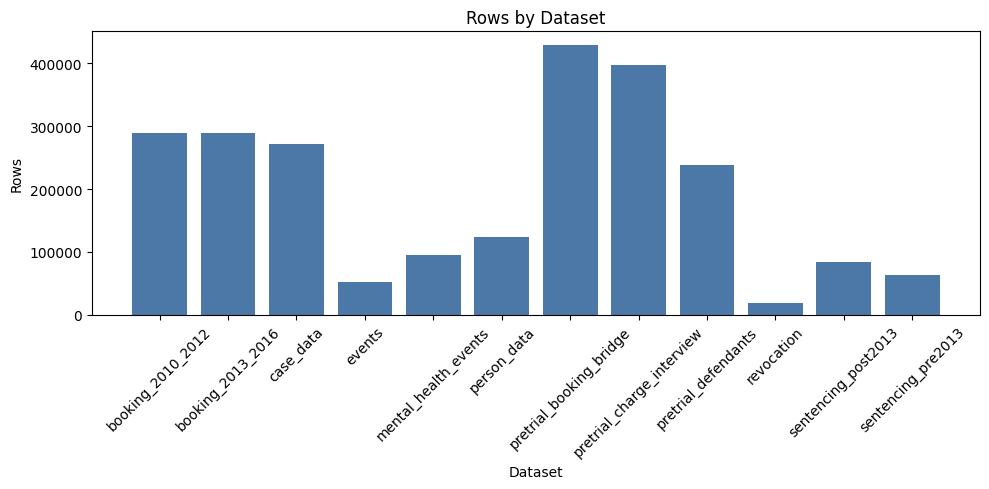

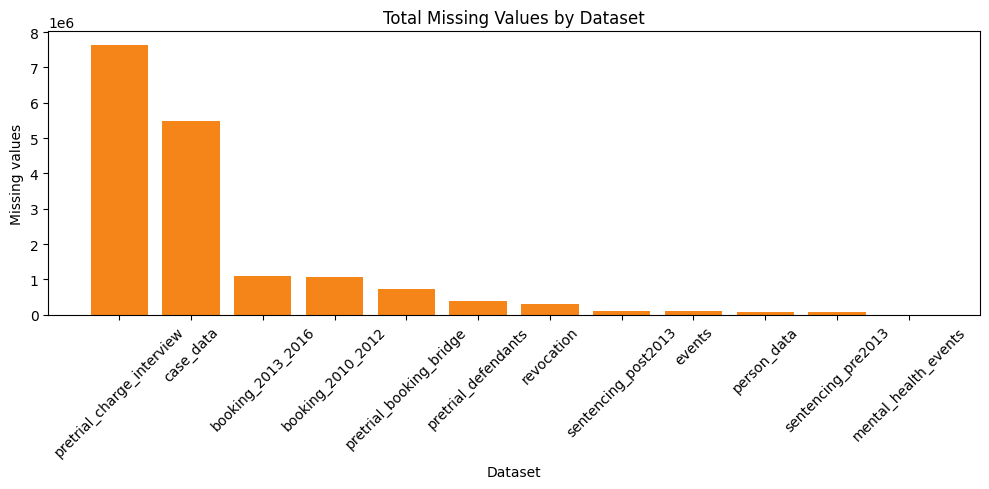

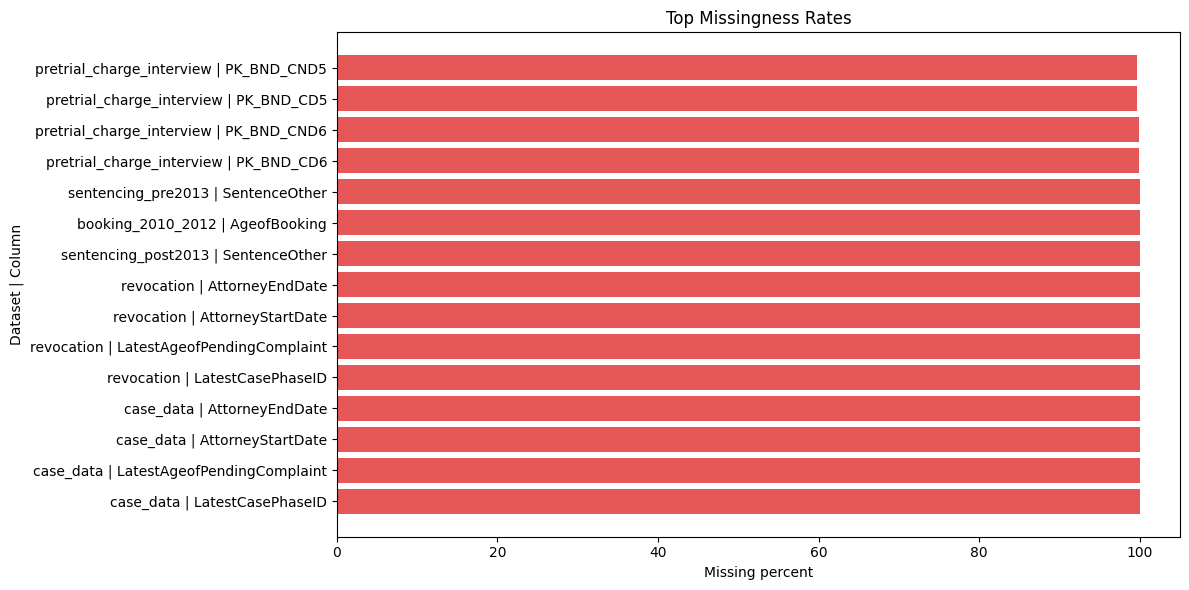

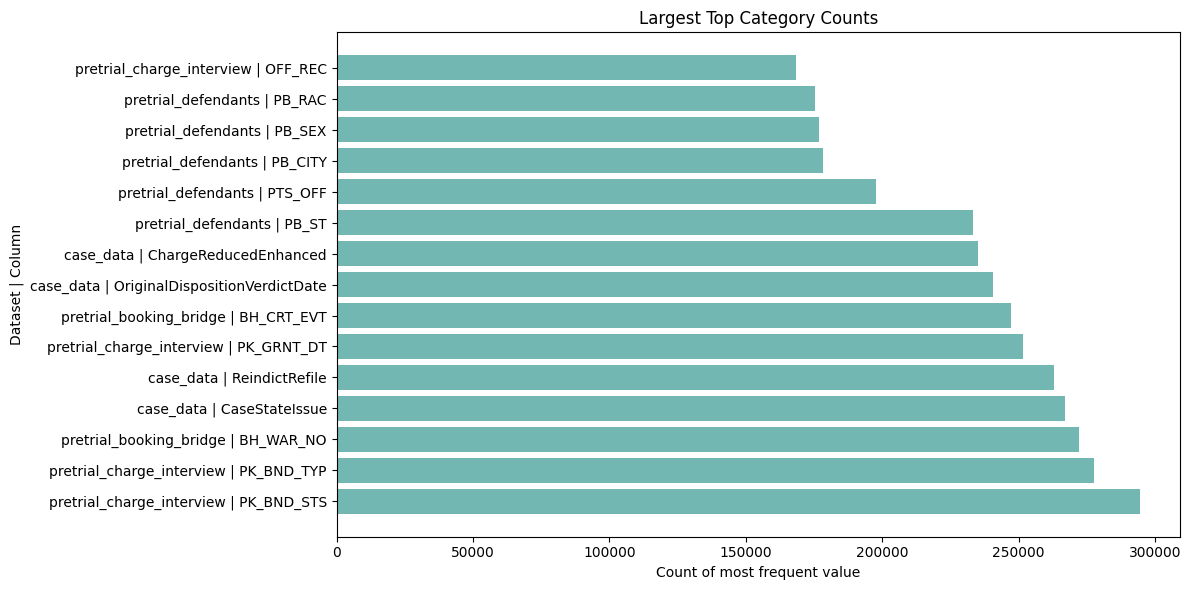

,dataset,rows,columns,duplicate_rows,duplicate_pct,numeric_columns,categorical_columns
0,booking_2010_2012,289061,43,0,0.00,26,17
1,booking_2013_2016,289869,43,0,0.00,26,17
2,case_data,271699,81,0,0.00,56,25
3,events,52853,16,0,0.00,12,3
4,mental_health_events,94336,7,1,0.00,3,2
5,person_data,123571,7,5130,4.15,5,1
6,pretrial_booking_bridge,429635,11,0,0.00,4,4
7,pretrial_charge_interview,397886,37,0,0.00,5,32
8,pretrial_defendants,238567,13,0,0.00,3,8
9,revocation,19258,81,0,0.00,55,12


,dataset,missing_count
7,pretrial_charge_interview,7637833
2,case_data,5473670
1,booking_2013_2016,1087436
0,booking_2010_2012,1078037
6,pretrial_booking_bridge,729549
8,pretrial_defendants,400623
9,revocation,303851
10,sentencing_post2013,110996
3,events,105894
5,person_data,82705


,dataset,column,missing_pct
86,case_data,LatestCasePhaseID,100.000000
87,case_data,LatestAgeofPendingComplaint,100.000000
88,case_data,AttorneyStartDate,100.000000
89,case_data,AttorneyEndDate,100.000000
258,revocation,LatestCasePhaseID,100.000000
259,revocation,LatestAgeofPendingComplaint,100.000000
260,revocation,AttorneyStartDate,100.000000
261,revocation,AttorneyEndDate,100.000000
353,sentencing_post2013,SentenceOther,99.983375
0,booking_2010_2012,AgeofBooking,99.972324


,dataset,column,count
52,pretrial_charge_interview,PK_BND_STS,294471
53,pretrial_charge_interview,PK_BND_TYP,277764
44,pretrial_booking_bridge,BH_WAR_NO,272151
26,case_data,CaseStateIssue,266897
34,case_data,ReindictRefile,263019
57,pretrial_charge_interview,PK_GRNT_DT,251774
42,pretrial_booking_bridge,BH_CRT_EVT,247320
33,case_data,OriginalDispositionVerdictDate,240653
28,case_data,ChargeReducedEnhanced,235086
63,pretrial_defendants,PB_ST,233445


Figures saved to: C:\Users\khade\Documents\GitHub\Bias-and-Fairness-in-AI-governance\reports\figures\travis_county_basic_eda


In [14]:
from pathlib import Path
import importlib.util
import subprocess
import sys

import pandas as pd
from IPython.display import display

if importlib.util.find_spec("matplotlib") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])

import matplotlib.pyplot as plt

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
eda_table_dir = project_root / "reports" / "tables" / "travis_county_basic_eda"
eda_figure_dir = project_root / "reports" / "figures" / "travis_county_basic_eda"
eda_figure_dir.mkdir(parents=True, exist_ok=True)

dataset_overview_df = pd.read_csv(eda_table_dir / "dataset_overview.csv")
missing_summary_df = pd.read_csv(eda_table_dir / "missing_values.csv")
categorical_value_counts_df = pd.read_csv(eda_table_dir / "categorical_value_counts_top10.csv")

missing_by_dataset_df = missing_summary_df.groupby("dataset", as_index=False)["missing_count"].sum().sort_values("missing_count", ascending=False)

top_missing_columns_df = missing_summary_df.sort_values(["missing_pct", "missing_count"], ascending=[False, False]).head(15)

top_categorical_counts_df = categorical_value_counts_df.groupby(["dataset", "column"], as_index=False)["count"].max().sort_values("count", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dataset_overview_df["dataset"], dataset_overview_df["rows"], color="#4C78A8")
ax.set_title("Rows by Dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Rows")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(eda_figure_dir / "rows_by_dataset.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(missing_by_dataset_df["dataset"], missing_by_dataset_df["missing_count"], color="#F58518")
ax.set_title("Total Missing Values by Dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Missing values")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(eda_figure_dir / "missing_values_by_dataset.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_missing_columns_df["dataset"] + " | " + top_missing_columns_df["column"], top_missing_columns_df["missing_pct"], color="#E45756")
ax.set_title("Top Missingness Rates")
ax.set_xlabel("Missing percent")
ax.set_ylabel("Dataset | Column")
fig.tight_layout()
fig.savefig(eda_figure_dir / "top_missingness_columns.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_categorical_counts_df["dataset"] + " | " + top_categorical_counts_df["column"], top_categorical_counts_df["count"], color="#72B7B2")
ax.set_title("Largest Top Category Counts")
ax.set_xlabel("Count of most frequent value")
ax.set_ylabel("Dataset | Column")
fig.tight_layout()
fig.savefig(eda_figure_dir / "top_categorical_value_counts.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

display(dataset_overview_df)
display(missing_by_dataset_df)
display(top_missing_columns_df[["dataset", "column", "missing_pct"]])
display(top_categorical_counts_df)

print(f"Figures saved to: {eda_figure_dir}")

## Grouped Visual Exploration

> Goal: create interpretable exploration plots for missingness, demographic distributions, risk scores, outcomes, and group-level comparisons using a merged pretrial analysis frame.

In [ ]:
from pathlib import Path
import importlib.util
import subprocess
import sys

import numpy as np
import pandas as pd
from IPython.display import display

if importlib.util.find_spec("matplotlib") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])

import matplotlib.pyplot as plt

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
raw_data_dir = project_root / "data" / "raw"
viz_output_dir = project_root / "reports" / "figures" / "travis_county_grouped_viz"
viz_output_dir.mkdir(parents=True, exist_ok=True)

person_df = pd.read_excel(raw_data_dir / "PersonData.xlsx", sheet_name="PersonData")
pretrial_defendants_df = pd.read_excel(raw_data_dir / "PreTrial Defendants.xlsx", sheet_name="Sheet1")
pretrial_charge_df = pd.read_csv(raw_data_dir / "PreTrial Charge-Interview.csv", low_memory=False)

def clean_blank_strings(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    cleaned = df[columns].copy()
    for column in columns:
        if cleaned[column].dtype == "object":
            cleaned[column] = cleaned[column].replace(r"^\s*$", np.nan, regex=True)
    return cleaned

pretrial_defendant_columns = [
    "PA_MAST_NO", "PA_BKG_NO", "BJ_BK_DATE", "PA_PTS_RISK", "PB_MNI",
    "PB_SEX", "PB_RAC", "PB_DOB", "PB_CITY", "PB_ST", "PB_ZIP", "PC_ETHNIC",
]
pretrial_charge_columns = [
    "PA_MAST_NO", "PK_BKG_NO", "BJ_BK_DATE", "PK_BND_GRT", "PK_BND_AMT",
    "PK_BND_TYP", "PK_BND_STS", "PK_CHARGE", "PK_CHG_LIT", "PK_LVL", "JUDGE",
]

pretrial_defendants_unique = (
    clean_blank_strings(pretrial_defendants_df, pretrial_defendant_columns)
    .sort_values("PA_MAST_NO")
    .groupby("PA_MAST_NO", as_index=False)
    .first()
 )

pretrial_charge_unique = (
    clean_blank_strings(pretrial_charge_df, pretrial_charge_columns)
    .sort_values("PA_MAST_NO")
    .groupby("PA_MAST_NO", as_index=False)
    .first()
 )

analysis_df = pretrial_defendants_unique.merge(pretrial_charge_unique, on="PA_MAST_NO", how="left", suffixes=("_def", "_chg"))
analysis_df = analysis_df.merge(person_df[["MNI", "GenderID", "RaceID", "EthnicityID"]], left_on="PB_MNI", right_on="MNI", how="left")

analysis_df["booking_date"] = pd.to_datetime(analysis_df["BJ_BK_DATE_def"].combine_first(analysis_df["BJ_BK_DATE_chg"]), errors="coerce")
analysis_df["dob"] = pd.to_datetime(analysis_df["PB_DOB"], errors="coerce")
analysis_df["age_at_booking"] = ((analysis_df["booking_date"] - analysis_df["dob"]).dt.days / 365.25).round(1)
analysis_df.loc[(analysis_df["age_at_booking"] < 0) | (analysis_df["age_at_booking"] > 100), "age_at_booking"] = np.nan
analysis_df["age_group"] = pd.cut(
    analysis_df["age_at_booking"],
    bins=[0, 24, 34, 44, 54, 64, 100],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"],
    include_lowest=True,
 )

analysis_df["PA_PTS_RISK_num"] = pd.to_numeric(analysis_df["PA_PTS_RISK"], errors="coerce")
analysis_df["PK_BND_AMT_num"] = pd.to_numeric(analysis_df["PK_BND_AMT"], errors="coerce")
analysis_df["bond_granted_flag"] = analysis_df["PK_BND_GRT"].astype(str).str.upper().map({"Y": 1, "N": 0})

analysis_df["race_display"] = analysis_df["PB_RAC"].fillna("<MISSING>").astype(str)
analysis_df["gender_display"] = analysis_df["PB_SEX"].fillna("<MISSING>").astype(str)
analysis_df["zip_display"] = analysis_df["PB_ZIP"].fillna("<MISSING>").astype(str)

selected_missing_cols = [
    "PB_SEX", "PB_RAC", "PB_DOB", "PB_ZIP", "PC_ETHNIC", "PA_PTS_RISK",
    "PK_BND_GRT", "PK_BND_AMT", "PK_BND_TYP", "PK_BND_STS", "PK_CHARGE", "JUDGE",
    "age_at_booking", "bond_granted_flag",
]
missing_plot_df = pd.DataFrame({
    "column": selected_missing_cols,
    "missing_pct": [analysis_df[col].isna().mean() * 100 for col in selected_missing_cols],
}).sort_values("missing_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(missing_plot_df["column"], missing_plot_df["missing_pct"], color="#E45756")
ax.set_title("Missingness in Key Pretrial Analysis Fields")
ax.set_xlabel("Missing percent")
ax.set_ylabel("Column")
fig.tight_layout()
fig.savefig(viz_output_dir / "key_field_missingness.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

race_counts = analysis_df["race_display"].value_counts().head(10)
gender_counts = analysis_df["gender_display"].value_counts().head(10)
age_counts = analysis_df["age_group"].astype(str).value_counts().reindex(["18-24", "25-34", "35-44", "45-54", "55-64", "65+", "nan"], fill_value=0)
zip_counts = analysis_df.loc[analysis_df["zip_display"] != "<MISSING>", "zip_display"].value_counts().head(10).sort_values()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].bar(race_counts.index.astype(str), race_counts.values, color="#4C78A8")
axes[0, 0].set_title("Race Distribution")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].bar(gender_counts.index.astype(str), gender_counts.values, color="#F58518")
axes[0, 1].set_title("Gender Distribution")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].bar(age_counts.index.astype(str), age_counts.values, color="#54A24B")
axes[1, 0].set_title("Age Group Distribution")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].barh(zip_counts.index.astype(str), zip_counts.values, color="#B279A2")
axes[1, 1].set_title("Top ZIP Code Counts")

fig.suptitle("Key Demographic Distributions", fontsize=14)
fig.tight_layout()
fig.savefig(viz_output_dir / "demographic_distributions.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

risk_counts = analysis_df["PA_PTS_RISK_num"].dropna().round().astype(int).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(risk_counts.index.astype(str), risk_counts.values, color="#72B7B2")
ax.set_title("Pretrial Risk Score Distribution")
ax.set_xlabel("Risk score")
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(viz_output_dir / "risk_score_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

bond_grant_counts = analysis_df["PK_BND_GRT"].fillna("<MISSING>").astype(str).str.upper().value_counts()
bond_amount_plot = analysis_df.loc[analysis_df["PK_BND_AMT_num"].between(0, analysis_df["PK_BND_AMT_num"].quantile(0.99), inclusive="both"), "PK_BND_AMT_num"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(bond_grant_counts.index.astype(str), bond_grant_counts.values, color="#ECA82C")
axes[0].set_title("Bond Grant Outcomes")
axes[0].set_xlabel("PK_BND_GRT")
axes[0].set_ylabel("Count")

axes[1].hist(bond_amount_plot, bins=30, color="#4C9F70", edgecolor="white")
axes[1].set_title("Bond Amount Distribution (Trimmed at 99th Percentile)")
axes[1].set_xlabel("Bond amount")
axes[1].set_ylabel("Count")

fig.tight_layout()
fig.savefig(viz_output_dir / "outcome_distributions.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

race_grant_df = analysis_df.groupby("race_display", as_index=False)["bond_granted_flag"].mean().dropna().sort_values("bond_granted_flag", ascending=False).head(10)
gender_grant_df = analysis_df.groupby("gender_display", as_index=False)["bond_granted_flag"].mean().dropna().sort_values("bond_granted_flag", ascending=False)
age_grant_df = analysis_df.groupby("age_group", as_index=False)["bond_granted_flag"].mean().dropna()
zip_grant_df = analysis_df[analysis_df["zip_display"] != "<MISSING>"].groupby("zip_display", as_index=False).agg(record_count=("PA_MAST_NO", "size"), bond_granted_rate=("bond_granted_flag", "mean"))
zip_grant_df = zip_grant_df[zip_grant_df["record_count"] >= 100].sort_values("bond_granted_rate", ascending=False).head(10)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].bar(race_grant_df["race_display"].astype(str), race_grant_df["bond_granted_flag"], color="#4C78A8")
axes[0, 0].set_title("Bond Grant Rate by Race")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].set_ylim(0, 1)

axes[0, 1].bar(gender_grant_df["gender_display"].astype(str), gender_grant_df["bond_granted_flag"], color="#F58518")
axes[0, 1].set_title("Bond Grant Rate by Gender")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].set_ylim(0, 1)

axes[1, 0].bar(age_grant_df["age_group"].astype(str), age_grant_df["bond_granted_flag"], color="#54A24B")
axes[1, 0].set_title("Bond Grant Rate by Age Group")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].set_ylim(0, 1)

axes[1, 1].barh(zip_grant_df["zip_display"].astype(str), zip_grant_df["bond_granted_rate"], color="#B279A2")
axes[1, 1].set_title("Bond Grant Rate by ZIP (Top 10 with >=100 records)")
axes[1, 1].set_xlim(0, 1)

fig.suptitle("Group-Level Outcome Comparisons", fontsize=14)
fig.tight_layout()
fig.savefig(viz_output_dir / "group_level_bond_grant_comparisons.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

display(missing_plot_df)
display(race_grant_df)
display(gender_grant_df)
display(age_grant_df)
display(zip_grant_df)

print(f"Visualization figures saved to: {viz_output_dir}")